# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

1. A model is "linear" because it applies weight to individual variables and combines them into a linear combination to make a prediction
2. the amount represents the expected difference in outcome compared to baseline category.
3. No, linear regression is designed for predicting numeric target variables, where classification tasks require predicting categorical label.
4. adding variables improve the model's accuracy on training data, but reduces accuracy on test data.
5. You regress a variable on all other variables and save residuals, if two variables are highly correlated, they explain the saem varation and cancel each other out, leading to inaccuracy.
6. By expanding your feature space with polynomial features and interaction terms, or by passing the linear equation
7. How much the target variable is expected to change for a one unit increase in a specific feature, assuming all other varables are held constant
8. This divides the data to evaluate how the model handles unseen data, while K fold cross validation divides data into multiple folds and iteratively test the model across them, heavily used for selecting optimal hyperparameters.
9. Typically uses 10 folds as standard choice

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
**Manhattan is the most expensive bourough on average 183.66**
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
**I dropped the first category, the bronx to serve as baseline.. The model's intercept (75.28) exactly matches the average price of the Bronx from part 1. The other coefficients math the difference between each neighborhood's average price and the Bronx's average price. The intercept is equal to the conditional mean of dropped baseline, the estimated coefficient represents the exact difference between a specific group conditional mean and the baseline conditional mean**
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
**Slope coefficient of 1.02 means that every one point increase in property's review scores rating, the expected nightly price increases by 1.02**
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change? **The slope for the review score rating increases from 1.02, meaning that controlling for neighborhood, each additional rating point increases the expected nightly price by 1.08. The neighborhood coefficient also adjust, thye now represent the difference in expected price compared to the Bronx baseline, assuming the review score is held constant**
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
**No, the slopes are not similar across neighborhoods. The effect of a 1-point increase in reivew score rating ranges from just .22 in bronx to 1.44 in Manhattan, meaning there is a premium you can charge foor a higher review score depending on ur location**
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

Averages by Neighbourhood:
                     Price  Review Scores Rating
Neighbourhood                                  
Bronx           75.276498             91.654378
Brooklyn       127.747378             92.363497
Manhattan      183.664286             91.801496
Queens          96.857233             91.549057
Staten Island  146.166667             90.843750


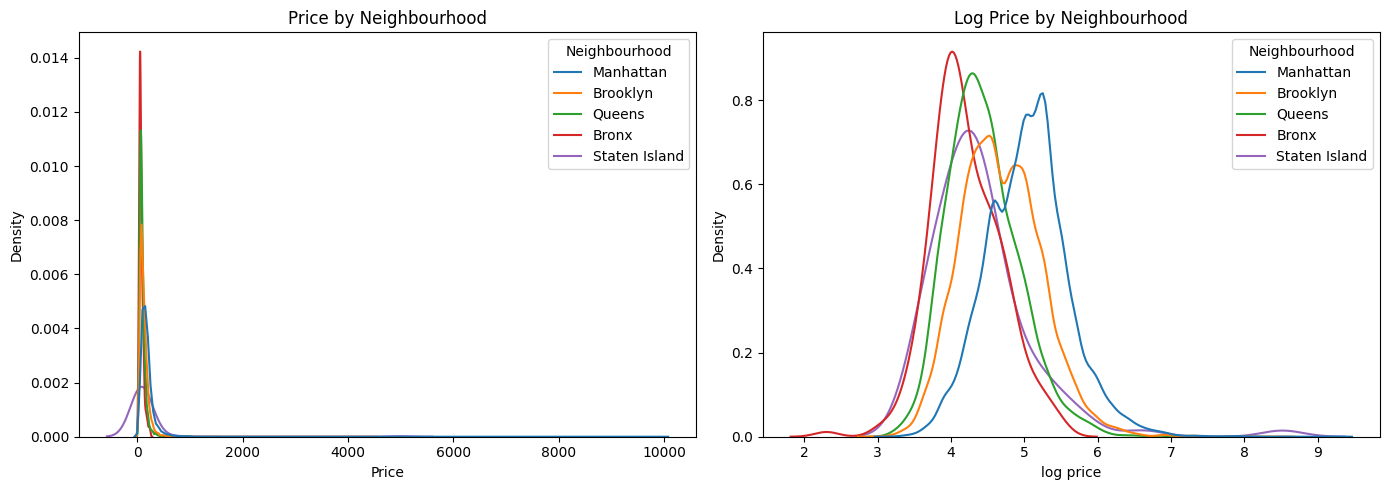

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/data/Q1_clean.csv')
df.head()

df.columns = df.columns.str.strip()

averages = df[['Price', 'Review Scores Rating', 'Neighbourhood']].groupby('Neighbourhood').mean()
print("Averages by Neighbourhood:\n", averages)

df['log price'] = np.log(df['Price'])


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=df, x='Price', hue='Neighbourhood', common_norm=False, ax=axes[0])
axes[0].set_title("Price by Neighbourhood")

sns.kdeplot(data=df, x='log price', hue='Neighbourhood', common_norm=False, ax=axes[1])
axes[1].set_title("Log Price by Neighbourhood")

plt.tight_layout()
plt.show()

In [16]:
from sklearn.linear_model import LinearRegression

X = pd.get_dummies(df['Neighbourhood'], drop_first=True, dtype=int)
y = df['Price']

model = LinearRegression()
model.fit(X, y)

print(f"Intercept: {model.intercept_}")
print(pd.DataFrame({'Neighbourhood': model.feature_names_in_, 'Coefficient': model.coef_}))

Intercept: 75.27649769585331
   Neighbourhood  Coefficient
0       Brooklyn    52.470881
1      Manhattan   108.387789
2         Queens    21.580735
3  Staten Island    70.890169


In [17]:
df_clean = df.dropna(subset=['Price', 'Review Scores Rating'])
X = df_clean[['Review Scores Rating']]
y = df_clean['Price']

model = LinearRegression()
model.fit(X, y)

print(f"Intercept: {model.intercept_}")
print(f"Slope (Review Scores Rating): {model.coef_}")

Intercept: 60.878390657123546
Slope (Review Scores Rating): [1.0208266]


In [18]:
df_clean = df.dropna(subset=['Price', 'Neighbourhood', 'Review Scores Rating'])
X_neigh = pd.get_dummies(df_clean['Neighbourhood'], drop_first=True, dtype=int)
X_both = pd.concat([X_neigh, df_clean[['Review Scores Rating']]], axis=1)
y = df_clean['Price']

model_both = LinearRegression()
model_both.fit(X_both, y)

print(model_both.intercept_)
print(pd.DataFrame({'Variable': model_both.feature_names_in_, 'Coefficient': model_both.coef_}))

-23.812561011672244
               Variable  Coefficient
0              Brooklyn    51.704240
1             Manhattan   108.228737
2                Queens    21.694600
3         Staten Island    71.766552
4  Review Scores Rating     1.081116


In [19]:
X_puzzle = pd.get_dummies(df_clean['Neighbourhood'], dtype=int).multiply(df_clean['Review Scores Rating'], axis=0)
model_puzzle = LinearRegression()
model_puzzle.fit(X_puzzle, y)

print(model_puzzle.intercept_)
print(pd.DataFrame({'Variable': model_puzzle.feature_names_in_, 'Coefficient': model_puzzle.coef_}))

55.11825364116355
        Variable  Coefficient
0          Bronx     0.222718
1       Brooklyn     0.790947
2      Manhattan     1.399376
3         Queens     0.456451
4  Staten Island     0.682444


In [20]:
from sklearn.model_selection import cross_val_score

cv_neigh = -cross_val_score(LinearRegression(), X_neigh, y, cv=5, scoring='neg_mean_squared_error').mean()
cv_both = -cross_val_score(LinearRegression(), X_both, y, cv=5, scoring='neg_mean_squared_error').mean()
cv_puzzle = -cross_val_score(LinearRegression(), X_puzzle, y, cv=5, scoring='neg_mean_squared_error').mean()

print(cv_neigh)
print(cv_both)
print(cv_puzzle)

21199.93842099436
21113.112422262097
21086.42384467359


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  **SUVs are the both the most expensive car type on average and most variance**
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  **Slope coefficient is 59268, meaning expected price increases roughly 59268 rupees for every additional seat. The relationship is not linear, as the dummy coefficients flucuate wildly**
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
**9 is optimal**
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?
  **No, it follows the general trend, but does seem to be overfitting**


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64
           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0

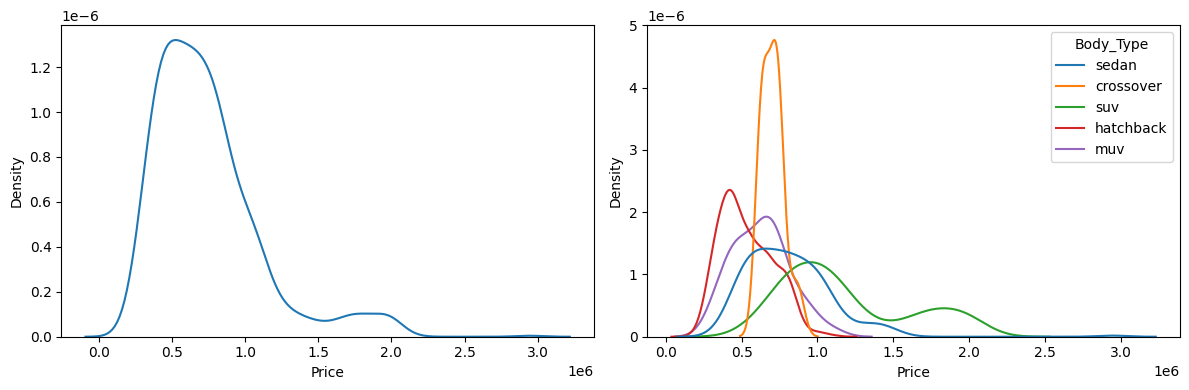

[59267.99803672]
   Seats   Coefficient
0      5  5.464839e+05
1      6  1.456000e+06
2      7  7.359487e+05
3      8  2.718000e+05


In [29]:
df = pd.read_csv('/content/data/cars_hw.csv')

print(df['Price'].describe())
print(df.groupby('Body_Type')['Price'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.kdeplot(data=df, x='Price', ax=axes[0])
sns.kdeplot(data=df, x='Price', hue='Body_Type', common_norm=False, ax=axes[1])
plt.tight_layout()
plt.show()

df_clean = df.dropna(subset=['Price', 'Seating_Capacity'])
X_num = df_clean[['Seating_Capacity']]
y = df_clean['Price']

model_num = LinearRegression()
model_num.fit(X_num, y)
print(model_num.coef_)

coef_df = pd.DataFrame({
    'Seats': X_cat.columns,
    'Coefficient': model_cat.coef_
})
print(coef_df)

In [25]:
from sklearn.preprocessing import PolynomialFeatures

df = df.dropna(subset=['Price', 'Make_Year']).copy()
df['Age'] = df['Make_Year'].max() - df['Make_Year']

X = df[['Age']]
y = df['Price']

mses = []
degrees = range(1, 11)

for d in degrees:
    X_poly = PolynomialFeatures(degree=d, include_bias=False).fit_transform(X)
    mse = -cross_val_score(LinearRegression(), X_poly, y, cv=10, scoring='neg_mean_squared_error').mean()
    mses.append(mse)

best_degree = degrees[mses.index(min(mses))]
print(best_degree)


9


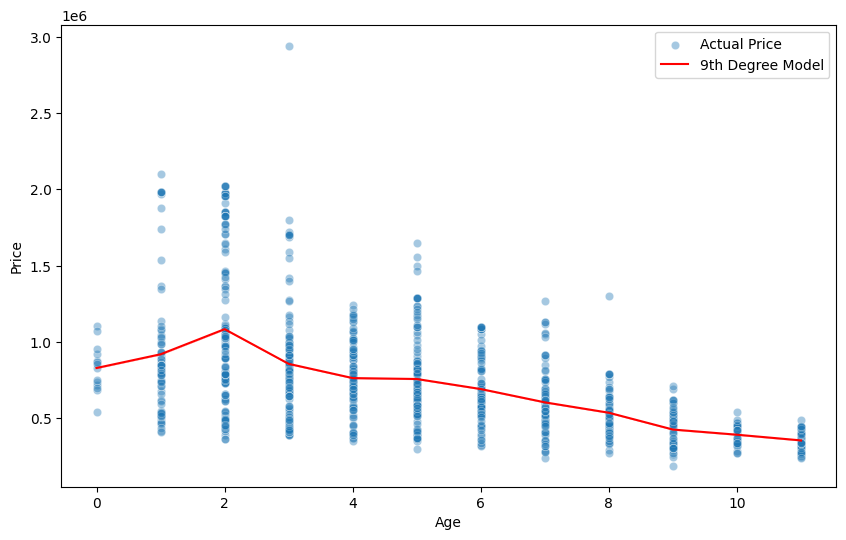

In [30]:
df_clean = df.dropna(subset=['Price', 'Make_Year']).copy()
df_clean['Age'] = df_clean['Make_Year'].max() - df_clean['Make_Year']

X = df_clean[['Age']]
y = df_clean['Price']

X_poly = PolynomialFeatures(degree=9, include_bias=False).fit_transform(X)
model = LinearRegression().fit(X_poly, y)

df_clean['Predicted_Price'] = model.predict(X_poly)
df_plot = df_clean.sort_values(by='Age')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_plot, x='Age', y='Price', alpha=0.4, label='Actual Price')
sns.lineplot(data=df_plot, x='Age', y='Predicted_Price', color='red', label='9th Degree Model')
plt.show()

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions? **intercept exactly matches contrrol groups survival rate (11.8%) and the transplant coefficient (23%) is matches ATE**
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. **replicates the results from part1**
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant? **When controlling for age, the transplant coefficient increases to 0.265. This means that assuming age is held constant, the surgery increases the expected chance of survival by 26.5%
. The intercept (0.702) represents the baseline survival probability for a 0-year-old without a transplant, and the age slope (-0.014) means survival probability drops by about 1.4% for every year of age.**
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?**The negative interaction term (-0.015) shows the transplant's survival benefit shrinks as patients get older. The surgery is highly effective for younger patients, but that benefit drops off with age.**
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. **he interaction model is the most accurate predictor. It scored the lowest Mean Squared Error (0.196) during the 10-fold cross-validation.**
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment? **Linear models shouldn't be used for binary outcomes because they can predict impossible probabilities, like values below 0 or above 1
. Plus, using this simple model for life-or-death decisions ignores other medical factors and lacks a real causal identification strategy**


transplant
control      0.117647
treatment    0.347826
Name: y, dtype: float64
0.23017902813299232
0.1176470588235293 [0.23017903]
0.7019569721740947 [ 0.26470169 -0.01360722]


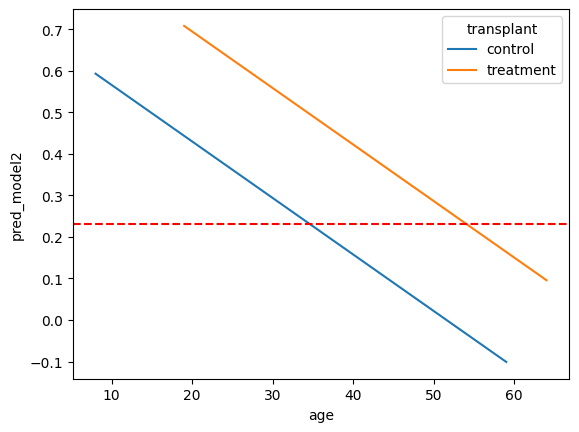

0.35486517529945855 [ 0.90775139 -0.00552426 -0.01459064]


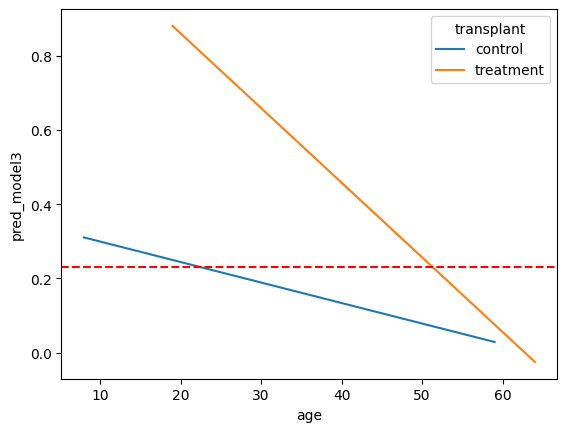

0.20970277289824915 0.19922806049232317 0.19609811380122735


In [33]:
df = pd.read_csv('/content/data/heart_hw.csv')

prop = df.groupby('transplant')['y'].mean()
print(prop)
ate = prop['treatment'] - prop['control']
print(ate)

X_trans = pd.get_dummies(df['transplant'], drop_first=True, dtype=int)
y = df['y']
model1 = LinearRegression().fit(X_trans, y)
print(model1.intercept_, model1.coef_)

X_age = df[['age']]
X_both = pd.concat([X_trans, X_age], axis=1)
model2 = LinearRegression().fit(X_both, y)
print(model2.intercept_, model2.coef_)

df['pred_model2'] = model2.predict(X_both)
plt.figure()
sns.lineplot(data=df, x='age', y='pred_model2', hue='transplant')
plt.axhline(y=ate, color='r', linestyle='--')
plt.show()

X_interact = X_trans.multiply(df['age'], axis=0)
X_interact.columns = ['treatment_x_age']
X_full = pd.concat([X_trans, X_age, X_interact], axis=1)
model3 = LinearRegression().fit(X_full, y)
print(model3.intercept_, model3.coef_)

df['pred_model3'] = model3.predict(X_full)
plt.figure()
sns.lineplot(data=df, x='age', y='pred_model3', hue='transplant')
plt.axhline(y=ate, color='r', linestyle='--')
plt.show()

cv1 = -cross_val_score(LinearRegression(), X_trans, y, cv=10, scoring='neg_mean_squared_error').mean()
cv2 = -cross_val_score(LinearRegression(), X_both, y, cv=10, scoring='neg_mean_squared_error').mean()
cv3 = -cross_val_score(LinearRegression(), X_full, y, cv=10, scoring='neg_mean_squared_error').mean()
print(cv1, cv2, cv3)